# Beijing PM2.5 Forecasting  
## Notebook 03 — Data Cleaning & Missing Value Handling

In this notebook, we handle missing values identified during EDA.

Our goal is **not** to aggressively “fix” the data, but to:
- Preserve time-series continuity
- Avoid distorting extreme pollution events
- Apply variable-specific, physically reasonable methods

All decisions here are guided by insights from the EDA notebook.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

## 1. Load Baseline Dataset

We load the baseline dataset created in `01_data_loading.ipynb`. This ensures consistency across the entire pipeline.

In [2]:
DATA_PATH = "../data/processed/aotizhongxin_baseline.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["datetime"], index_col="datetime")

df.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
datetime,,,,,,,,,,,,
2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4
2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7
2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6
2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1
2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0


## 2. Missing Values Recap

From EDA, we observed:
- Weather variables have very few missing values
- Pollutant variables have small but non-negligible gaps
- Missing values occur in short, localized intervals

We now handle each variable group accordingly.

In [3]:
# Missing vlaues summaru before cleaning

missing_before = df.isna().sum()
missing_before

PM2.5     925
PM10      718
SO2       935
NO2      1023
CO       1776
O3       1719
TEMP       20
PRES       20
DEWP       20
RAIN       20
wd         81
WSPM       14
dtype: int64

## 3. Cleaning Strategy Overview

We apply different strategies based on variable type:

### Weather variables
- Smooth physical processes
- Very few missing values
- Linear interpolation

### Pollutant variables (including PM2.5)
- High variance, extreme spikes
- Missing due to sensor downtime
- Time-based interpolation with limits

### Wind direction (`wd`)
- Categorical variable
- Very small gaps
- Forward-fill

In [4]:
pollutants = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
weather_vars = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

In [5]:
print(pollutants)
print(weather_vars)

['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


## 4. Weather Variables — Linear Interpolation

Weather variables change gradually over time. Linear interpolation is appropriate and low-risk here.

In [ ]:
# Interpolate weather variables
df[weather_vars] = df[weather_vars].interpolate(
    method="time"
)

## 5. Pollutant Variables — Controlled Time Interpolation

Pollutant concentrations can change rapidly.
To avoid over-smoothing extreme pollution events, we:
- Interpolate only short gaps
- Do not extrapolate across long missing periods

In [7]:
# Interpolate Pollutants (With Limits)
df[pollutants] = df[pollutants].interpolate(
    method="time",
    limit=6,
    limit_direction="both"
)

## 6. Wind Direction (`wd`) Handling

Wind direction is categorical and shows very few missing values. We forward-fill to preserve directional continuity.

In [9]:
df["wd"] = df["wd"].ffill()

## 7. Remaining Missing Values Check

After controlled interpolation, we check if any missing values remain.

In [12]:
missing_after = df.isna().sum()
missing_after

PM2.5    463
PM10     401
SO2      511
NO2      470
CO       880
O3       587
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
dtype: int64

In [13]:
df_clean = df.dropna()

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))

Rows before cleaning: 35064
Rows after cleaning: 33902


In [10]:
df.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
datetime,,,,,,,,,,,,
2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4
2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7
2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6
2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1
2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0


In [11]:
df.tail()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
datetime,,,,,,,,,,,,
2017-02-28 19:00:00,12.0,29.0,5.0,35.0,400.0,95.0,12.5,1013.5,-16.2,0.0,NW,2.4
2017-02-28 20:00:00,13.0,37.0,7.0,45.0,500.0,81.0,11.6,1013.6,-15.1,0.0,WNW,0.9
2017-02-28 21:00:00,16.0,37.0,10.0,66.0,700.0,58.0,10.8,1014.2,-13.3,0.0,NW,1.1
2017-02-28 22:00:00,21.0,44.0,12.0,87.0,700.0,35.0,10.5,1014.4,-12.9,0.0,NNW,1.2
2017-02-28 23:00:00,19.0,31.0,10.0,79.0,600.0,42.0,8.6,1014.1,-15.9,0.0,NNE,1.3


## 9. Save Cleaned Dataset

This cleaned dataset will be used for:
- Feature engineering
- Baseline models
- XGBoost
- LSTM

In [15]:
OUTPUT_PATH = "../data/processed/aotizhongxin_clean.csv"

df_clean.to_csv(OUTPUT_PATH)

print(f"Cleaned dataset saved to: {OUTPUT_PATH}")

Cleaned dataset saved to: ../data/processed/aotizhongxin_clean.csv


## 10. Cleaning Summary

In this notebook, we:
- Used EDA to guide all cleaning decisions
- Preserved time-series continuity
- Avoided aggressive data removal
- Applied variable-specific, physically reasonable methods

The cleaned dataset remains realistic and suitable for time-series forecasting with machine learning models.

## EDA using the cleaned data

## PM2.5 Time Series (After Cleaning)

Purpose: Verify continuity and ensure no unexpected gaps or artifacts were introduced.

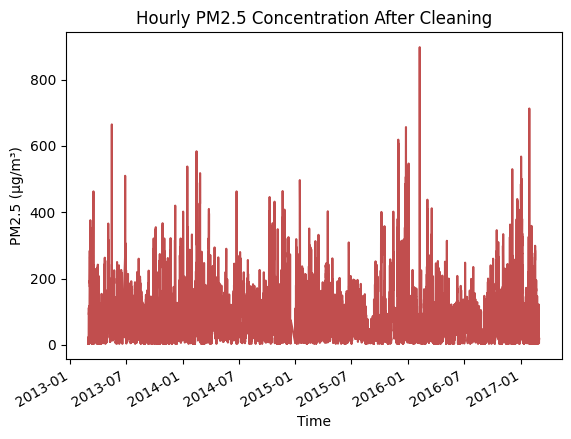

In [16]:
import matplotlib.pyplot as plt

df_clean["PM2.5"].plot(color="firebrick", alpha=0.8)
plt.title("Hourly PM2.5 Concentration After Cleaning")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Time")
plt.show()

## Monthly Average PM2.5 (Seasonality Check)

Purpose: Confirm seasonal trends remain after cleaning.

C:\Users\ibaan\AppData\Local\Temp\ipykernel_20492\886585877.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_pm25 = df_clean["PM2.5"].resample("M").mean()


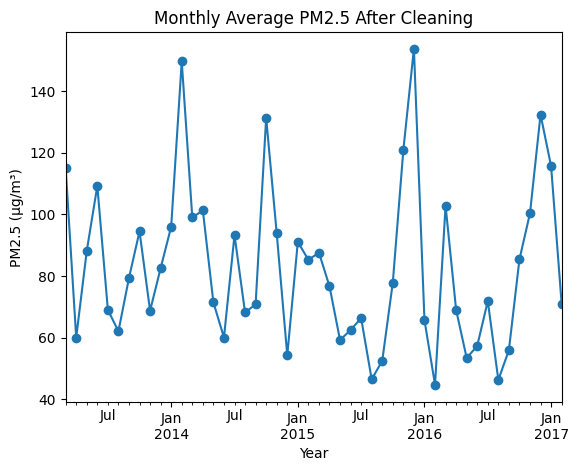

In [18]:
monthly_pm25 = df_clean["PM2.5"].resample("M").mean()

monthly_pm25.plot(marker="o")
plt.title("Monthly Average PM2.5 After Cleaning")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Year")
plt.show()

## Hour-of-Day Pattern (Diurnal Cycle)

Purpose:Ensure daily pollution patterns were not disrupted.

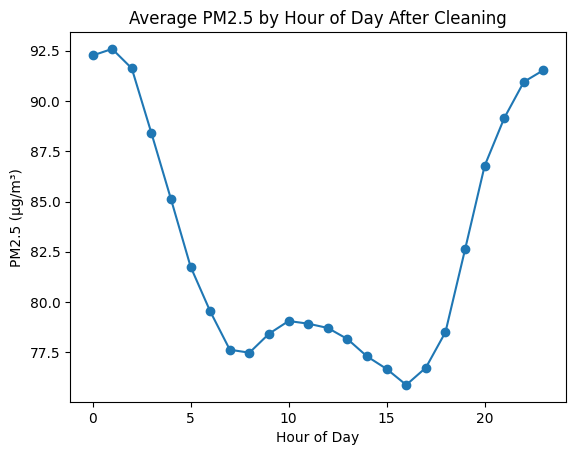

In [19]:
hourly_pattern = df_clean.groupby(df_clean.index.hour)["PM2.5"].mean()

hourly_pattern.plot(marker="o")
plt.title("Average PM2.5 by Hour of Day After Cleaning")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

## Pollutant Correlation Heatmap (After Cleaning)

Purpose: Confirm relationships between pollutants remain consistent.

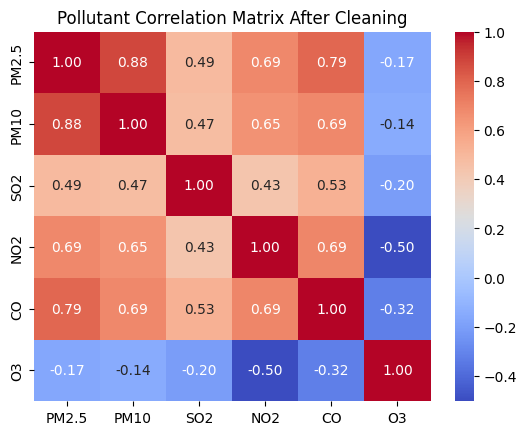

In [20]:
import seaborn as sns

pollutants = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
corr = df_clean[pollutants].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pollutant Correlation Matrix After Cleaning")
plt.show()

## Post-Cleaning EDA — Key Validation Observations

The post-cleaning EDA confirms that the data-cleaning process did not distort
the underlying structure of the dataset:

- **Temporal continuity is preserved**: the hourly PM2.5 time series remains continuous, with extreme pollution spikes still present and no artificial flat segments introduced.
- **Seasonal patterns remain intact**: monthly average PM2.5 continues to show higher concentrations in winter and lower levels in summer, consistent with known Beijing air-quality behavior.
- **Daily (diurnal) cycles are unchanged**: PM2.5 remains higher during nighttime and early morning hours, with a clear dip during midday, indicating that short-gap interpolation and row removal did not disrupt daily patterns.
- **Pollutant relationships are stable**: strong positive correlations between PM2.5, PM10, NO₂, and CO are preserved, while O₃ maintains its negative relationship with PM2.5.
- **No structural bias introduced**: the removal of approximately 3.3% of rows did not alter distributions, correlations, or temporal trends.